# Model Attribution

## Using Variance/Mean Based Classifier Trained in Stage 3 to Calibrate Against Multi-class Data and Ultimately Perform Multi-class Classification or Model-Attribution

### Imports

In [1]:
import sys
import shutil
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.nn as nn

from transformers import AutoImageProcessor, ViTImageProcessor, ViTMAEModel

import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from torch.optim.lr_scheduler import LambdaLR
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import json
import os
import random
from tqdm.auto import tqdm



### Device Availability Check

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple GPU
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
    print("Using CUDA")
else:
    device = torch.device("cpu")   # fallback
    print("Using CPU")

Using CUDA


### Mount G-drive and Unzip Files

In [4]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_SOURCE = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL_3.5/dataset.zip"
    DATASET_ROOT = "/content/Dataset/dataset"

    if not os.path.exists(DATASET_ROOT):
        print("Copying zip from Drive to local runtime (faster unzipping)...")
        # Copy to local disk /content/ to avoid Drive I/O during unzip
        shutil.copy(ZIP_SOURCE, "/content/dataset.zip")
        print("Unzipping dataset...")
        shutil.unpack_archive("/content/dataset.zip", "/content/Dataset")
        #MODEL_DIR = MODEL_ROOT
        print("Done!")
    else:
        print("Dataset already extracted.")
else:
    DEFAULT_ROOT = ""
    DATASET_ROOT = os.getenv("DATASET_ROOT", DEFAULT_ROOT)


TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")
VAL_DIR = os.path.join(DATASET_ROOT, "Val")


# --- 1. Define Paths ---
MODEL_ZIP = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL_3.5/myMAE.zip"
MODEL_DIR = "/content/myMAE"  # This is where we will unzip to

# --- 2. Unzip if necessary ---
if not os.path.exists(MODEL_DIR):
    print("Copying and unzipping model...")
    shutil.copy(MODEL_ZIP, "/content/myMAE.zip")
    shutil.unpack_archive("/content/myMAE.zip", MODEL_DIR)
    print("Model extracted to /content/myMAE")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Copying and unzipping model...
Model extracted to /content/myMAE


### Hyperparameters

In [5]:
DATA_LOADER_BATCH_SIZE = 32
DATA_LOADER_NUM_WORKERS = 2

NUM_EPOCHS = 25
LEARNING_RATE = 3e-4

PATIENCE = 10

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

### Pre-processor

In [6]:
processor = AutoImageProcessor.from_pretrained(MODEL_DIR)
def transform(image):
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


### Data-Loaders

In [7]:
# Datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=transform)
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=True, # only shuffle training data
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Class mapping check
print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Specifically identify the 'Real' index for your baseline
REAL_IDX = class_to_idx["Real"]

print(f"Active Class Mapping: {class_to_idx}")

Classes: ['Diffusion', 'GAN', 'IFv1', 'Real']
Class to idx: {'Diffusion': 0, 'GAN': 1, 'IFv1': 2, 'Real': 3}
Active Class Mapping: {'Diffusion': 0, 'GAN': 1, 'IFv1': 2, 'Real': 3}


### Class Distribution

In [8]:
def get_class_counts(dataset):
    # ImageFolder stores labels in dataset.targets
    return Counter(dataset.targets)

train_counts = get_class_counts(train_dataset)
val_counts   = get_class_counts(val_dataset)
test_counts  = get_class_counts(test_dataset)

def map_counts(counts, dataset):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    return {
        idx_to_class[i]: counts.get(i, 0)
        for i in range(len(idx_to_class))
    }
print("\nTrain total:", sum(train_counts.values()))
print("Validation total:", sum(val_counts.values()))
print("Test total:", sum(test_counts.values()))

print("\nTrain class counts:", map_counts(train_counts, train_dataset))
print("Validation class counts:", map_counts(val_counts, val_dataset))
print("Test class counts:", map_counts(test_counts, test_dataset))


Train total: 4000
Validation total: 1000
Test total: 1000

Train class counts: {'Diffusion': 1000, 'GAN': 1000, 'IFv1': 1000, 'Real': 1000}
Validation class counts: {'Diffusion': 250, 'GAN': 250, 'IFV1': 250, 'Real': 250}
Test class counts: {'Diffusion': 250, 'GAN': 250, 'IFv1': 250, 'Real': 250}


### Model Instantiation

In [9]:
myMAE = ViTMAEModel.from_pretrained(MODEL_DIR)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: /content/myMAE
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_norm.weight                                                      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attenti

### Model Definition

In [10]:
class MAEVarianceClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Load the pretrained ViT-MAE model as the encoder
        self.encoder = myMAE
        # Freeze the encoder parameters to prevent training
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.hidden_dim = self.encoder.config.hidden_size  # = 768 = the feature dimension

        # MLP head
        self.classifier = nn.Sequential(
          nn.LayerNorm(self.hidden_dim * 2),
          nn.Linear(self.hidden_dim * 2, 512),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(512, 128),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(128, num_classes)
        )

    def forward(self, pixel_values, return_features=False):
      outputs = self.encoder(pixel_values=pixel_values)

      patches = outputs.last_hidden_state[:, 1:, :]
      var_vector = patches.var(dim=1, unbiased=False)
      mean_vector = patches.mean(dim=1)

      features = torch.cat([mean_vector, var_vector], dim=1)

      logits = self.classifier(features)

      if return_features:
          return logits, features
      return logits

### Model Initialization

In [11]:
model = MAEVarianceClassifier(num_classes=4) # Multi-Class Classification : IFv1, GAN, Diffusion, Real
model = model.to(device)

### Optimizer & Scheduler

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=2,
    min_lr=1e-6,
    threshold=1e-4,           # only treat improvement > 1e-4 as valid
    threshold_mode='rel'       # can also be 'abs'
)

### Training Function

In [13]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    model.encoder.eval()
    total_loss = 0
    correct = 0
    total = 0

    # tqdm for progress tracking
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc

### Validation

In [14]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total

### Training Loop

In [15]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
counter = 0

# Ensure encoder stays deterministic
model.encoder.eval()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Smooth val_loss for the scheduler (use raw val_loss for first epoch)
    if len(history["val_loss"]) == 0:
        smoothed_val = val_loss
    else:
        smoothed_val = 0.3 * val_loss + 0.7 * history["val_loss"][-1]

    # ---- Scheduler Step ----
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(smoothed_val)
    new_lr = optimizer.param_groups[0]['lr']

    # ---- Record history ----
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, "
          f"LR={new_lr:.6f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_variance_based_model.pt")
    else:
        counter += 1

        # Reset early stopping if LR was reduced
        if new_lr < old_lr:
            counter = 0

        if counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.1696, Train Acc=0.4695, Val Loss=1.0001, Val Acc=0.6200, LR=0.000300


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.9129, Train Acc=0.6165, Val Loss=0.8032, Val Acc=0.6880, LR=0.000300


Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 23: Train Loss=0.3056, Train Acc=0.8855, Val Loss=0.3239, Val Acc=0.8790, LR=0.000300


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 24: Train Loss=0.3002, Train Acc=0.8850, Val Loss=0.3324, Val Acc=0.8850, LR=0.000300


Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 25: Train Loss=0.2728, Train Acc=0.8935, Val Loss=0.3841, Val Acc=0.8570, LR=0.000300


### Loss and Accuracy Curves

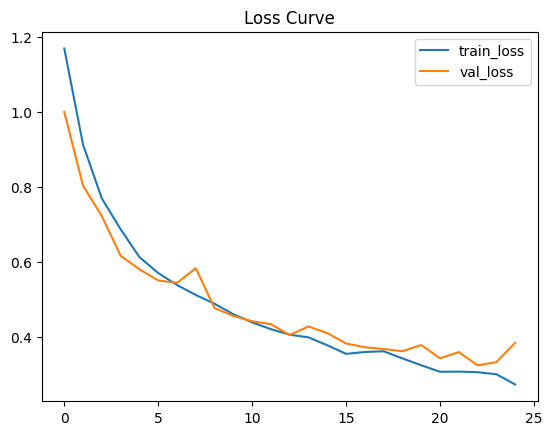

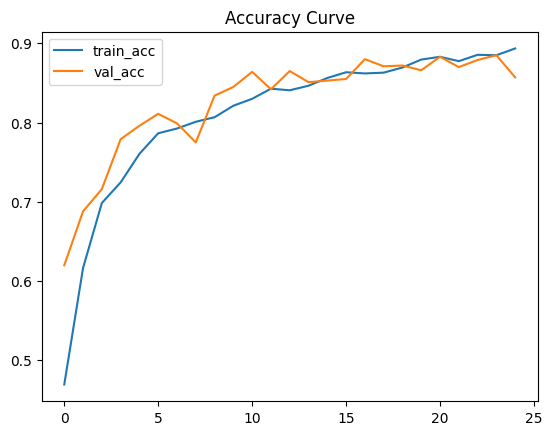

In [16]:
# Loss
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

# Accuracy
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.show()

### Testing

In [17]:
model.load_state_dict(torch.load("best_variance_based_model.pt"))
model.eval()

y_true = []
y_pred = []
y_probs = [] # Now storing all 4 class probabilities

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 1. Get raw logits from the 4-output head
        logits = model(images)

        # 2. Convert to probabilities for all classes
        probs = torch.softmax(logits, dim=1)

        # 3. Get the ACTUAL predicted class index (0, 1, 2, or 3)
        _, preds = torch.max(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# Print a quick check
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

              precision    recall  f1-score   support

   Diffusion       0.86      0.92      0.89       250
         GAN       0.96      0.88      0.91       250
        IFv1       0.86      0.81      0.83       250
        Real       0.81      0.86      0.83       250

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



### Multiclass Metrics

In [18]:
# 1. Overall Accuracy
acc = accuracy_score(y_true, y_pred)

# 2. Multi-class Precision, Recall, F1 (Macro-averaged)
# 'macro' calculates metrics for each label and finds their unweighted mean.
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

# 3. Multi-class ROC-AUC
# This requires the full probability distribution (y_probs)
auc  = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')

metrics = {
    "accuracy": acc,
    "precision_macro": prec,
    "recall_macro": rec,
    "f1_score_macro": f1,
    "roc_auc_ovr": auc
}

print("--- Aggregate Metrics ---")
for k, v in metrics.items():
    print(f"{k:15}: {v:.4f}")

--- Aggregate Metrics ---
accuracy       : 0.8670
precision_macro: 0.8698
recall_macro   : 0.8670
f1_score_macro : 0.8673
roc_auc_ovr    : 0.9791


### OVR(One vs Rest) ROC-Curve

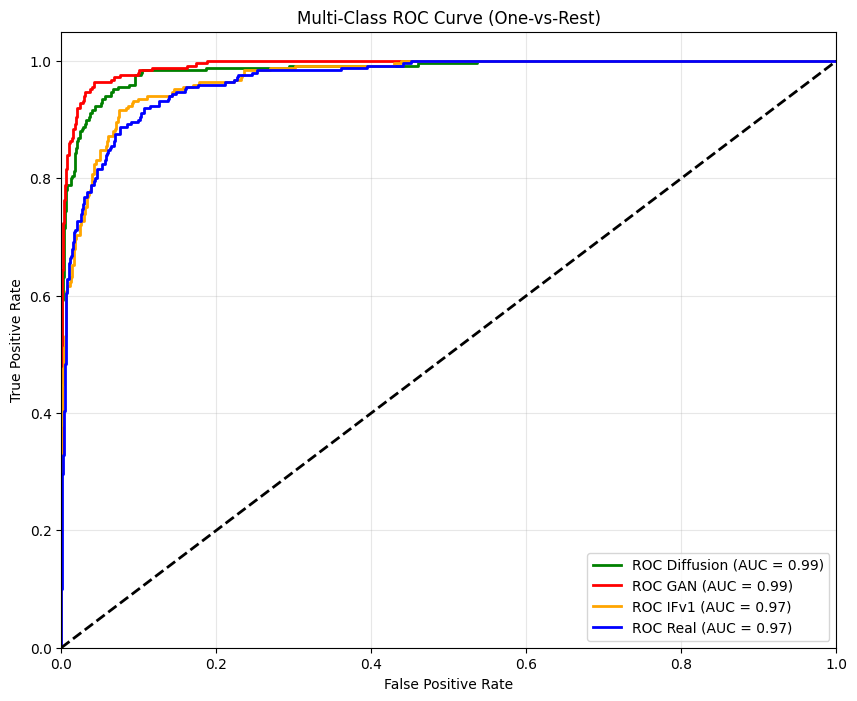

In [19]:
# 1. Binarize the labels for multi-class plotting
# This turns [0, 1, 2, 3] into [[1,0,0,0], [0,1,0,0]...]
classes = train_dataset.classes
n_classes = len(classes)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(10, 8))

# 2. Calculate ROC and AUC for each class
from sklearn.metrics import auc # Re-import to "reset" the function name
fpr = dict()
tpr = dict()
roc_auc_dict = {} # Renamed from roc_auc to avoid confusion

colors = ['green', 'red', 'orange', 'blue'] # Match your class order

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])

    # Use the function 'auc', but store the result in a different name
    current_auc = auc(fpr[i], tpr[i])
    roc_auc_dict[i] = current_auc

    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC {classes[i]} (AUC = {current_auc:.2f})')

# 3. Plot the "Chance" line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("multi_class_roc_curve.png")
plt.show()

### Confusion Matrix

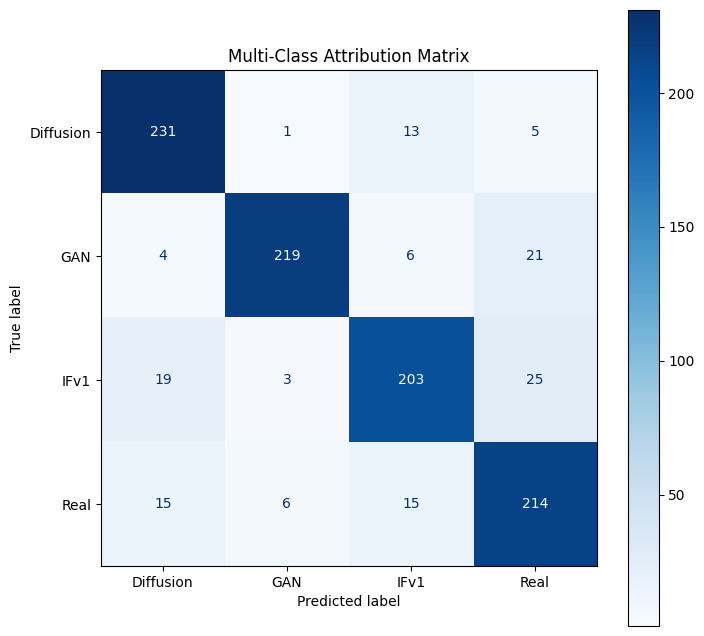

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure these are in the EXACT order of your indices 0, 1, 2, 3
actual_class_order = ['Diffusion', 'GAN', 'IFv1', 'Real']

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actual_class_order)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Multi-Class Attribution Matrix")
plt.show()

### Multi-Class Misclassifications

In [21]:


# class_names = ['Real', 'IFv1', 'Diffusion', 'GAN']
# And REAL_LABEL is the index for 'Real' (usually 0)
REAL_LABEL_IDX = train_dataset.class_to_idx['Real']

# 1. Find indices where the model was WRONG
# (Actual was Real, but Model predicted one of the 3 Fakes)
wrong_real_mask = (y_true == REAL_LABEL_IDX) & (y_pred != REAL_LABEL_IDX)
wrong_real_idx = np.where(wrong_real_mask)[0]

# 2. Find indices where the model missed a Fake
# (Actual was a Fake, but Model predicted 'Real')
missed_fake_mask = (y_true != REAL_LABEL_IDX) & (y_pred == REAL_LABEL_IDX)
missed_fake_idx = np.where(missed_fake_mask)[0]

# "Most Confident" Errors

# For 'Real' images called 'Fake':
# We want the ones where the probability of being 'Real' was lowest
confident_real_errors = wrong_real_idx[np.argsort(y_probs[wrong_real_idx, REAL_LABEL_IDX])[:5]]

# For 'Fake' images called 'Real':
# We want the ones where the probability of being 'Real' was highest
confident_fake_errors = missed_fake_idx[np.argsort(y_probs[missed_fake_idx, REAL_LABEL_IDX])[-5:]]

# Get the labels and max probs for display
real_err_probs = y_probs[confident_real_errors, REAL_LABEL_IDX]
fake_err_probs = y_probs[confident_fake_errors, REAL_LABEL_IDX]

### Multi-class Visualization Function

In [22]:
def show_and_save_images(indices, y_true, y_pred, y_probs, title, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    plt.figure(figsize=(15, 4))

    class_names = train_dataset.classes # ['Diffusion', 'GAN', 'IFv1', 'Real']

    for i, idx in enumerate(indices):
        # --- 1. GRAB THE IMAGE ---
        # test_dataset[idx][0] is the Tensor (C, H, W)
        img_tensor = test_dataset[idx][0]

        # --- 2. DENORMALIZE ---
        # Convert (C, H, W) -> (H, W, C) for matplotlib
        img = img_tensor.permute(1, 2, 0).numpy()

        # ViT-MAE normalization is mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = (img * std) + mean
        img = np.clip(img, 0, 1) # Ensure pixel values are in [0, 1]

        # --- 3. GET LABELS ---
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        conf = y_probs[idx][y_pred[idx]]

        # --- 4. SHOW ---
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(img)
        plt.title(f"T: {true_label}\nP: {pred_label}\nC: {conf:.2f}", fontsize=9)
        plt.axis('off')

        # --- 5. SAVE ---
        filename = f"{true_label}_as_{pred_label}_{i}.png"
        plt.imsave(os.path.join(save_dir, filename), img)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Labels and GT vs Pred

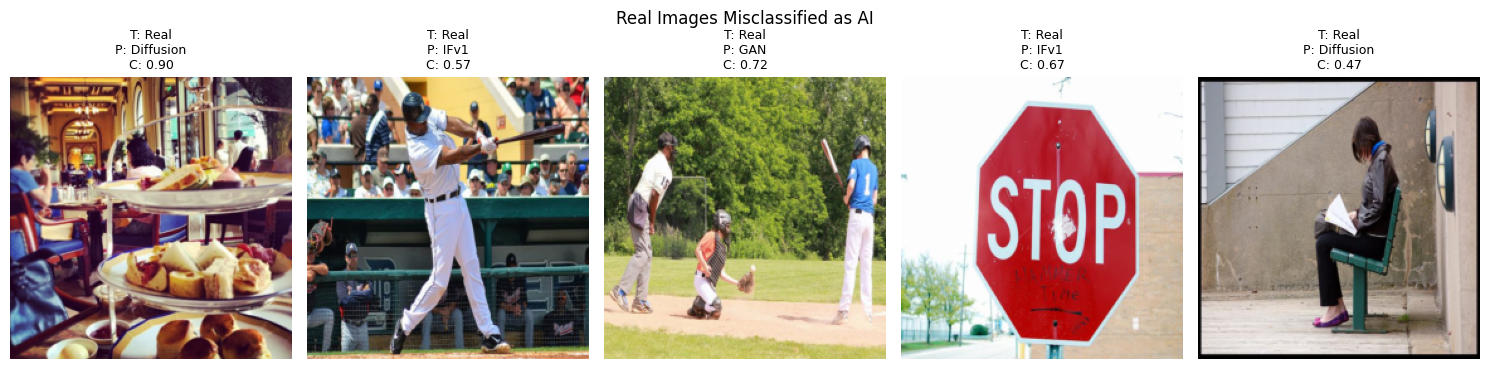

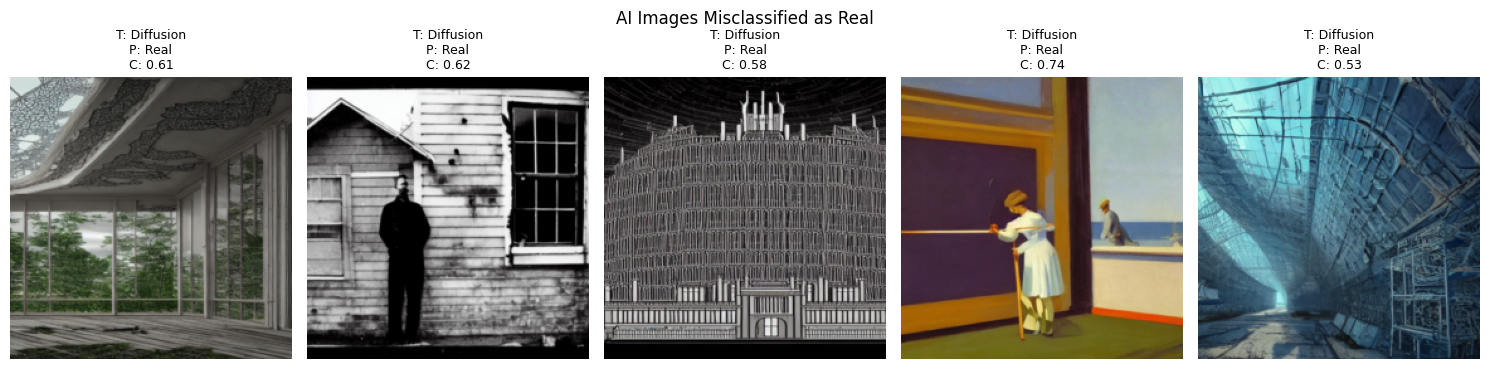

In [23]:
REAL_LABEL_IDX = train_dataset.class_to_idx['Real']

# 1. "Real as Fake": Actual is Real, but Model predicted ANY of the 3 fakes
real_as_fake_idx = np.where((y_true == REAL_LABEL_IDX) & (y_pred != REAL_LABEL_IDX))[0]

# 2. "Fake as Real": Actual is ANY of the 3 fakes, but Model predicted Real
fake_as_real_idx = np.where((y_true != REAL_LABEL_IDX) & (y_pred == REAL_LABEL_IDX))[0]

# 3. Grab the first 5 (or use the sorting logic from before to get the 'most confident')
real_samples = real_as_fake_idx[:5]
fake_samples = fake_as_real_idx[:5]

# 1. Map your indices to names
class_names = ["Real", "IFv1", "Diffusion", "GAN"]

# 2. Create the labels for "Real misclassified as Fake"
real_as_fake_labels = [
    f"Real_as_{class_names[y_pred[idx]]}_conf_{y_probs[idx][y_pred[idx]]:.2f}"
    for idx in real_samples
]

# 3. Create the labels for "Fakes misclassified as Real"
# (Since y_pred is 0 for these, it's always "as_Real")
fake_as_real_labels = [
    f"{class_names[y_true[idx]]}_as_Real_conf_{y_probs[idx][0]:.2f}"
    for idx in fake_samples
]

# 4. Call your existing function with these strings
show_and_save_images(
    indices=real_samples,
    y_true=y_true,
    y_pred=y_pred,
    y_probs=y_probs,
    title="Real Images Misclassified as AI",
    save_dir="outputs/real_as_fake"
)

show_and_save_images(
    indices=fake_samples,
    y_true=y_true,
    y_pred=y_pred,
    y_probs=y_probs,
    title="AI Images Misclassified as Real",
    save_dir="outputs/fake_as_real"
)

### Capture w_eff from gradients in Multi-class

In [24]:
model.eval()

MID_POINT = 768
REAL_LABEL_IDX = 3
num_classes = model.classifier[-1].out_features

class_names = ["Diffusion", "GAN", "IFv1", "Real"]
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
label_to_color = {i: colors[i] for i in range(num_classes)}

# Store contributions per hyperplane
all_proj_mean = {i: [] for i in range(num_classes)}
all_proj_var  = {i: [] for i in range(num_classes)}
all_labels    = {i: [] for i in range(num_classes)}

# FEATURE GRADIENT PROJECTION
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model.encoder(pixel_values=images)
    patches = outputs.last_hidden_state[:, 1:, :]
    mean_vector = patches.mean(dim=1)
    var_vector  = patches.var(dim=1, unbiased=False)
    features = torch.cat([mean_vector, var_vector], dim=1)

    for class_idx in range(num_classes):
        if class_idx == REAL_LABEL_IDX:
            continue

        # Use all images (not just Real + this fake) for context
        features_clone = features.clone().detach().requires_grad_(True)
        logits = model.classifier(features_clone)

        # Score is difference between this fake class vs Real
        score = (logits[:, class_idx] - logits[:, REAL_LABEL_IDX]).sum()
        model.zero_grad()
        score.backward()
        w_eff = features_clone.grad

        proj_mean = (features_clone[:, :MID_POINT] * w_eff[:, :MID_POINT]).sum(dim=1)
        proj_var  = (features_clone[:, MID_POINT:] * w_eff[:, MID_POINT:]).sum(dim=1)

        all_proj_mean[class_idx].extend(proj_mean.detach().cpu().numpy())
        all_proj_var[class_idx].extend(proj_var.detach().cpu().numpy())
        all_labels[class_idx].extend(labels.cpu().numpy())

### Multi-class mapping of var/mean separation in learned mlp space

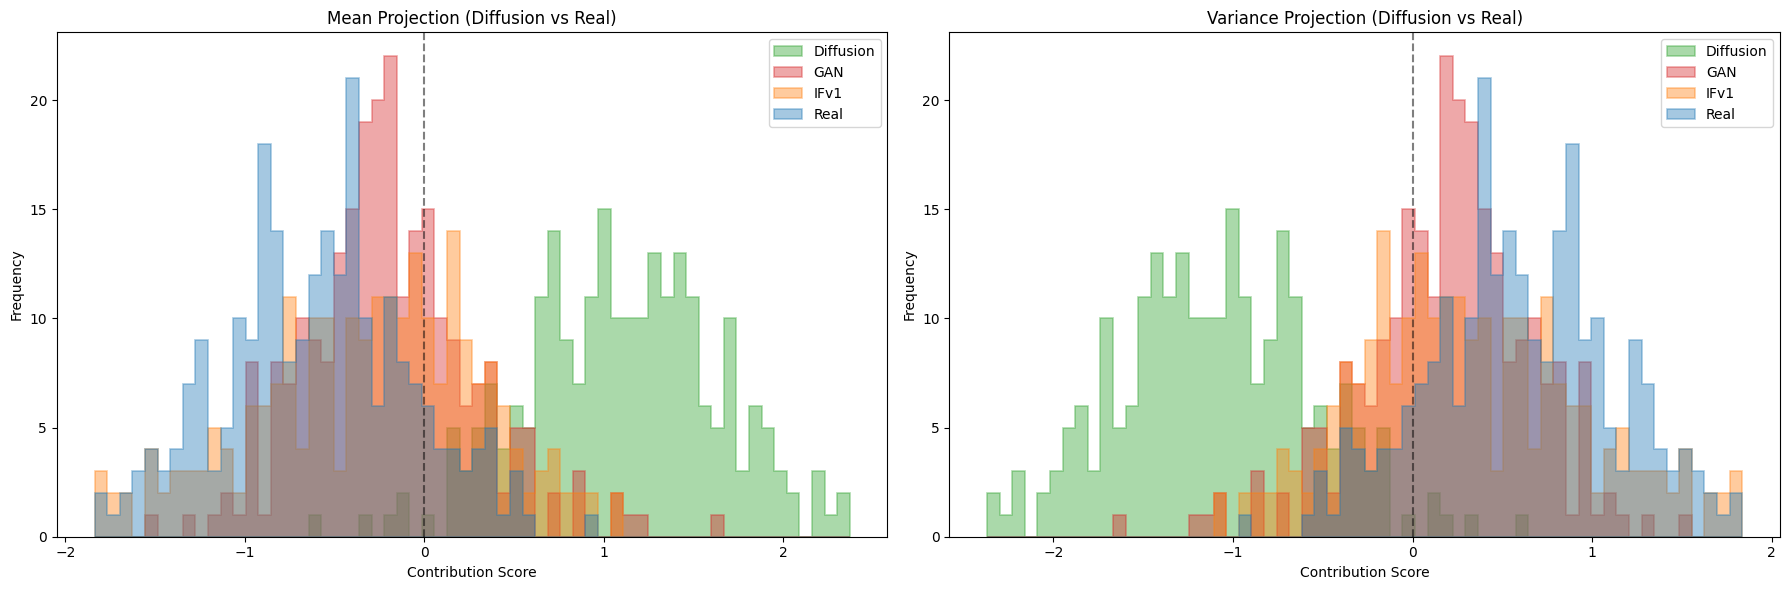

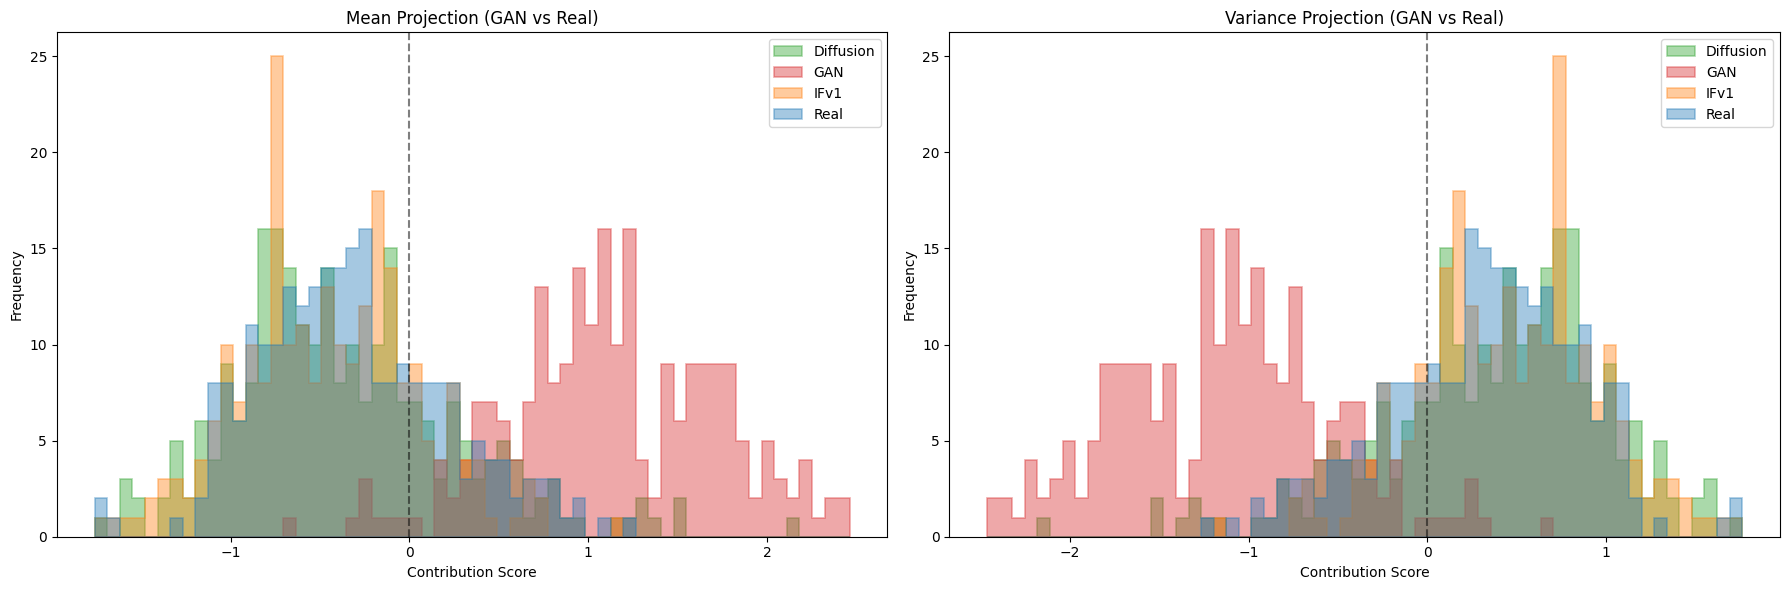

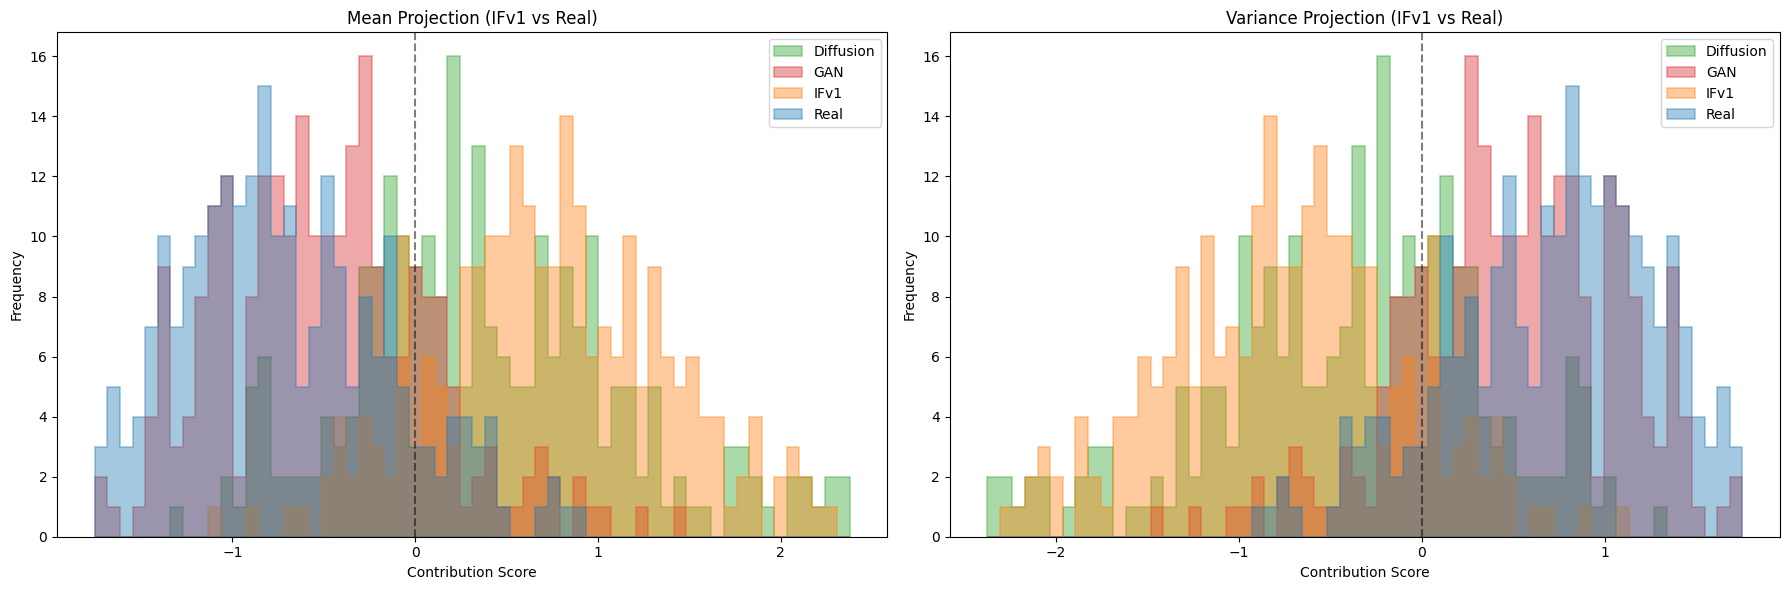

In [25]:
# PLOTTING FUNCTION

class_names = ["Diffusion", "GAN", "IFv1", "Real"]
def plot_multiclass_separation(data, labels, title, ax=None, class_names=None, colors=None):
    data = (data - np.mean(data)) / (np.std(data) + 1e-8)
    lower, upper = np.percentile(data, [2, 98])

    labels_unique = np.unique(labels)

    # Default class names
    if class_names is None:
        class_names = [str(lbl) for lbl in labels_unique]

    # Default colors
    if colors is None:
        # generate some default colors if not enough
        default_colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4', '#9467bd', '#8c564b']
        colors = {lbl: default_colors[i % len(default_colors)] for i, lbl in enumerate(labels_unique)}

    for lbl in labels_unique:
        class_data = data[labels == lbl]
        ax.hist(
            class_data,
            bins=60,
            range=(lower, upper),
            alpha=0.4,
            label=class_names[lbl] if lbl < len(class_names) else str(lbl),
            color=colors[lbl],
            edgecolor=colors[lbl],
            linewidth=1.2,
            histtype='stepfilled'
        )

    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Contribution Score")
    ax.set_ylabel("Frequency")
    ax.legend()

# PLOT PER FAKE CLASS HYPERPLANE
for class_idx in range(num_classes):
    if class_idx == REAL_LABEL_IDX:
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    plot_multiclass_separation(
        np.array(all_proj_mean[class_idx]),
        np.array(all_labels[class_idx]),
        f"Mean Projection ({class_names[class_idx]} vs Real)",
        ax=ax1,
        class_names=class_names  # full 4-class list
    )

    plot_multiclass_separation(
        np.array(all_proj_var[class_idx]),
        np.array(all_labels[class_idx]),
        f"Variance Projection ({class_names[class_idx]} vs Real)",
        ax=ax2,
        class_names=class_names  # full 4-class list
    )

    plt.tight_layout()
    plt.show()

### D-score

In [26]:
def calculate_d_prime(fake_scores, real_scores):
    fake_scores = np.array(fake_scores)
    real_scores = np.array(real_scores)

    mu_f, std_f = np.mean(fake_scores), np.std(fake_scores)
    mu_r, std_r = np.mean(real_scores), np.std(real_scores)

    # The d-prime formula: separation of means / average standard deviation
    d_prime = abs(mu_f - mu_r) / np.sqrt(0.5 * (std_f**2 + std_r**2))
    return d_prime

# Prepare the data for a nice DataFrame
results = []
class_names = {0: 'Diffusion', 1: 'GAN', 2: 'IFv1'} # Real is the baseline

for class_idx, name in class_names.items():
    # 1. Get the indices for the 'True' Real images and 'True' Fake images
    # within this specific class's projection list
    labels = np.array(all_labels[class_idx])

    # Projection scores for images that are ACTUALLY this fake class
    fake_proj_mean = np.array(all_proj_mean[class_idx])[labels == class_idx]
    fake_proj_var  = np.array(all_proj_var[class_idx])[labels == class_idx]

    # Projection scores for images that are ACTUALLY Real (the baseline)
    real_proj_mean = np.array(all_proj_mean[class_idx])[labels == REAL_LABEL_IDX]
    real_proj_var  = np.array(all_proj_var[class_idx])[labels == REAL_LABEL_IDX]

    # 2. Calculate scores
    d_mean = calculate_d_prime(fake_proj_mean, real_proj_mean)
    d_var  = calculate_d_prime(fake_proj_var, real_proj_var)

    results.append({
        "Generator": name,
        "Mean Separation (d')": round(d_mean, 3),
        "Var Separation (d')": round(d_var, 3),
        "Best Domain": "Mean" if d_mean > d_var else "Variance"
    })

# 3. Display as a Table
df_stats = pd.DataFrame(results)
print("Forensic Separation Statistics (d-prime):")
display(df_stats)

Forensic Separation Statistics (d-prime):


,Generator,Mean Separation (d'),Var Separation (d'),Best Domain
0,Diffusion,2.741,2.741,Variance
1,GAN,2.370,2.370,Variance
2,IFv1,2.221,2.221,Variance


### Separate logits extraction for plotting Real vs Rest

In [27]:
model.eval()

MID_POINT = 768
REAL_LABEL_IDX = REAL_LABEL_IDX
num_classes = model.classifier[-1].out_features

all_proj_mean = []
all_proj_var  = []
all_labels    = []

for images, labels in test_loader:
    images = images.to(device)

    outputs = model.encoder(pixel_values=images)
    patches = outputs.last_hidden_state[:, 1:, :]  # skip CLS token

    var_vector  = patches.var(dim=1, unbiased=False)
    mean_vector = patches.mean(dim=1)
    features = torch.cat([mean_vector, var_vector], dim=1)  # [batch, 1536]

    # Compute Real vs Rest logit difference
    features_clone = features.clone().detach().requires_grad_(True)
    logits = model.classifier(features_clone)

    # pick maximum fake logit per sample
    fake_logits = logits.clone()
    fake_logits[:, REAL_LABEL_IDX] = float('-inf')
    max_fake, _ = fake_logits.max(dim=1)

    # real vs rest score
    score = (logits[:, REAL_LABEL_IDX] - max_fake).sum()

    # backward to get gradient w.r.t features
    model.zero_grad()
    score.backward()

    w_eff = features_clone.grad  # gradient

    proj_mean = (features_clone[:, :MID_POINT] * w_eff[:, :MID_POINT]).sum(dim=1)
    proj_var  = (features_clone[:, MID_POINT:] * w_eff[:, MID_POINT:]).sum(dim=1)

    all_proj_mean.extend(proj_mean.detach().cpu().numpy())
    all_proj_var.extend(proj_var.detach().cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

### Plotting Real vs Rest

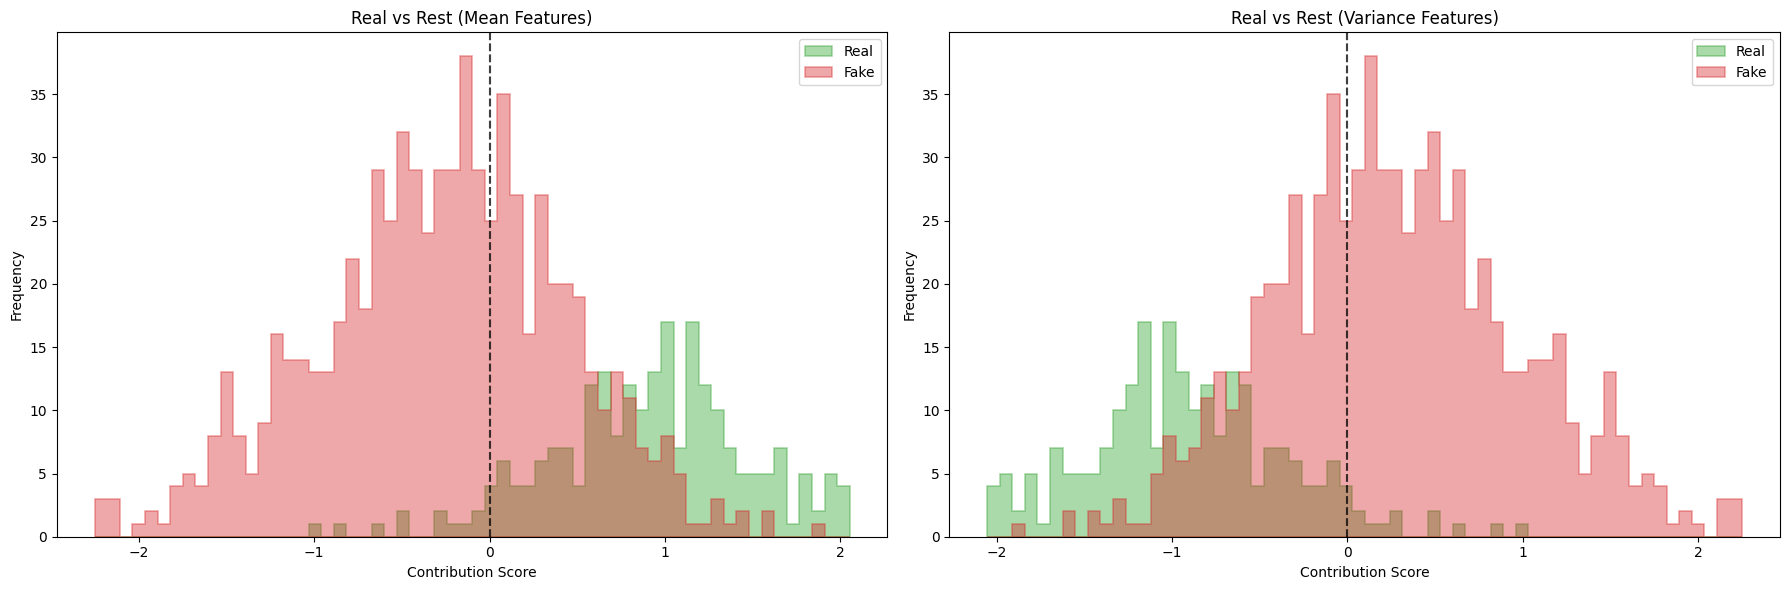

In [28]:
import matplotlib.pyplot as plt
import numpy as np

binary_labels = np.array([0 if lbl == REAL_LABEL_IDX else 1 for lbl in all_labels])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean projection
plot_multiclass_separation(
    all_proj_mean,
    binary_labels,
    title="Real vs Rest (Mean Features)",
    ax=axes[0],
    class_names=["Real", "Fake"]  # binary
)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Contribution Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Variance projection
plot_multiclass_separation(
    all_proj_var,
    binary_labels,
    title="Real vs Rest (Variance Features)",
    ax=axes[1],
    class_names=["Real", "Fake"]
)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Contribution Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()